In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List, Optional

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [32]:
class ToyMaskingOperator:
    """Random binary masking operator (Ambient Diffusion)"""
    def __init__(self, p: float = 0.6, delta: float = 0.1):
        self.p = p
        self.delta = delta

    def corrupt_and_hat_corrupt(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mask_A = (torch.rand_like(x) > self.p).float()
        mask_B = (torch.rand_like(x) > self.delta).float()
        hat_mask = mask_A * mask_B
        return mask_A, hat_mask


class PreconditionedScoreNet(nn.Module):
    """Score network with EDM preconditioning"""
    def __init__(self, in_dim: int = 2, hidden_dim: int = 512, num_layers: int = 3, sigma_data: float = 0.5):
        super().__init__()
        self.sigma_data = sigma_data
        self.in_dim = in_dim

        layers = []
        for i in range(num_layers):
            in_features = (in_dim * 2 + 1) if i == 0 else hidden_dim
            out_features = hidden_dim if i < num_layers - 1 else in_dim
            layers.append(nn.Linear(in_features, out_features))
            if i < num_layers - 1:
                layers.append(nn.GELU())

        self.net = nn.Sequential(*layers)

    def forward(self, x_tilde: torch.Tensor, sigma: torch.Tensor, hat_mask: torch.Tensor) -> torch.Tensor:
        c_skip = self.sigma_data**2 / (sigma**2 + self.sigma_data**2)
        c_out = sigma * self.sigma_data / (sigma**2 + self.sigma_data**2).sqrt()
        c_in = 1 / (sigma**2 + self.sigma_data**2).sqrt()
        c_noise = (sigma.log() / 4.0).expand(-1, 1)

        x_in = x_tilde * c_in
        cat_input = torch.cat([x_in, hat_mask, c_noise], dim=1)
        F_x = self.net(cat_input)
        D_x = c_skip * x_tilde + c_out * F_x
        return D_x


def get_scheduler(num_steps: int = 50, sigma_begin: float = 10.0, sigma_end: float = 0.01) -> torch.Tensor:
    """Create noise schedule"""
    return torch.exp(torch.linspace(np.log(sigma_begin), np.log(sigma_end), num_steps))

In [33]:
def generate_two_moons(n_samples: int = 20000, noise: float = 0.05) -> torch.Tensor:
    """Generates a normalized Two Moons dataset"""
    X_np, _ = make_moons(n_samples=n_samples, noise=noise)
    X_np = (X_np - X_np.mean(axis=0)) / X_np.std(axis=0)
    return torch.tensor(X_np, dtype=torch.float32)


def generate_gmm(n_samples: int = 100000, num_clusters: int = 3, seed: Optional[int] = None) -> torch.Tensor:
    """Generates a GMM dataset with configurable clusters"""
    if seed is not None:
        np.random.seed(seed)

    means = [np.array([4.0, 4.0]), np.array([-4.0, -4.0]), np.array([4.0, -3.0])][:num_clusters]
    covs = [
        np.array([[2.0, 1.8], [1.8, 2.0]]),
        np.array([[2.5, -2.0], [-2.0, 2.5]]),
        np.array([[0.3, 0.0], [0.0, 3.0]]),
    ][:num_clusters]

    choices = np.random.choice(list(range(num_clusters)), size=n_samples)
    X = np.zeros((n_samples, 2))
    for i in range(num_clusters):
        mask_c = choices == i
        X[mask_c] = np.random.multivariate_normal(means[i], covs[i], np.sum(mask_c))

    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return torch.tensor(X, dtype=torch.float32)

In [34]:
from tqdm import tqdm
from sklearn.neighbors import KernelDensity

def train_score_net(
    model: nn.Module,
    data: torch.Tensor,
    operator: ToyMaskingOperator,
    epochs: int = 1000,
    batch_size: int = 1024,
    sigma_data: float = 0.5,
    p_mean: float = -1.2,
    p_std: float = 1.2,
    lr: float = 5e-4,
) -> Tuple[nn.Module, List[float]]:
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in tqdm(range(epochs), desc="train_score_net"):
        idx = torch.randint(0, len(data), (batch_size,))
        y = data[idx].to(device)

        rnd_normal = torch.randn(batch_size, 1, device=device)
        sigma = (rnd_normal * p_std + p_mean).exp()
        weight = ((sigma**2 + sigma_data**2) / (sigma * sigma_data) ** 2)

        n = torch.randn_like(y) * sigma
        noisy_y = y + n

        mask_A, hat_mask = operator.corrupt_and_hat_corrupt(y)
        masked_noisy = hat_mask * noisy_y

        D_yn = model(masked_noisy, sigma, hat_mask)
        loss = torch.mean(weight * ((mask_A * (D_yn - y)) ** 2))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

    return model, history

def train_standard_diffusion(
    model: nn.Module,
    data: torch.Tensor,
    epochs: int = 1000,
    batch_size: int = 1024,
    sigma_data: float = 0.5,
    p_mean: float = -1.2,
    p_std: float = 1.2,
    lr: float = 5e-4,
) -> Tuple[nn.Module, List[float]]:
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in tqdm(range(epochs), desc="train_standard_diffusion"):
        idx = torch.randint(0, len(data), (batch_size,))
        y = data[idx].to(device)

        rnd_normal = torch.randn(batch_size, 1, device=device)
        sigma = (rnd_normal * p_std + p_mean).exp()
        weight = ((sigma**2 + sigma_data**2) / (sigma * sigma_data) ** 2)

        n = torch.randn_like(y) * sigma
        noisy_y = y + n
        dummy_mask = torch.ones_like(y, device=device)

        D_yn = model(noisy_y, sigma, dummy_mask)
        loss = torch.mean(weight * ((D_yn - y) ** 2))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

    return model, history

def train_naive_diffusion(
    model: nn.Module,
    data: torch.Tensor,
    operator: ToyMaskingOperator,
    epochs: int = 1000,
    batch_size: int = 1024,
    sigma_data: float = 0.5,
    p_mean: float = -1.2,
    p_std: float = 1.2,
    lr: float = 5e-4,
) -> Tuple[nn.Module, List[float]]:
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in tqdm(range(epochs), desc="train_naive_diffusion"):
        idx = torch.randint(0, len(data), (batch_size,))
        y = data[idx].to(device)

        rnd_normal = torch.randn(batch_size, 1, device=device)
        sigma = (rnd_normal * p_std + p_mean).exp()
        weight = ((sigma**2 + sigma_data**2) / (sigma * sigma_data) ** 2)

        mask_A, _ = operator.corrupt_and_hat_corrupt(y)
        y_corrupted = y * mask_A

        n = torch.randn_like(y_corrupted) * sigma
        noisy_y_corrupted = y_corrupted + n

        D_yn = model(noisy_y_corrupted, sigma, mask_A)
        loss = torch.mean(weight * ((mask_A * (D_yn - y_corrupted)) ** 2))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

    return model, history

def compute_metrics(real_data: torch.Tensor, generated_data: torch.Tensor, device=device) -> dict:
    """
    Compute KDE Log-Likelihood, MMD, and Sliced Wasserstein Distance.
    real_data and generated_data should be tensors of shape (N, 2).
    """
    min_samples = min(len(real_data), len(generated_data))

    real_np = real_data[:min_samples].cpu().numpy()
    gen_np = generated_data[:min_samples].cpu().numpy()

    real_t = real_data[:min_samples].to(device)
    gen_t = generated_data[:min_samples].to(device)

    metrics = {}

    kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(real_np)
    log_pdf = kde.score_samples(gen_np)
    metrics['KDE_LogLikelihood'] = np.mean(log_pdf)

    def rbf_kernel(x, y, sigma=1.0):
        dist = torch.cdist(x, y)**2
        return torch.exp(-dist / (2 * sigma**2))

    k_xx = rbf_kernel(real_t, real_t).mean()
    k_yy = rbf_kernel(gen_t, gen_t).mean()
    k_xy = rbf_kernel(real_t, gen_t).mean()
    metrics['MMD'] = (k_xx + k_yy - 2 * k_xy).item()

    num_projections = 50
    theta = torch.rand(num_projections, device=device) * 2 * np.pi
    projections = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)

    real_proj = torch.matmul(real_t, projections.T)
    gen_proj = torch.matmul(gen_t, projections.T)

    real_proj, _ = torch.sort(real_proj, dim=0)
    gen_proj, _ = torch.sort(gen_proj, dim=0)

    swd = torch.mean((real_proj - gen_proj)**2)
    metrics['SWD'] = swd.item()

    return metrics

def sample_score_net(
    model: nn.Module,
    num_samples: int,
    sigmas: torch.Tensor,
) -> np.ndarray:
    """Generate samples using an ODE solver."""
    model.eval()
    x_t = torch.randn(num_samples, 2, device=device) * 10.0
    mask = torch.ones_like(x_t)

    with torch.no_grad():
        for i in range(len(sigmas) - 1):
            sigma_t = sigmas[i].to(device)
            sigma_t_next = sigmas[i + 1].to(device)
            sigma_tensor = torch.full((num_samples, 1), sigma_t.item(), device=device)
            pred_x0 = model(mask * x_t, sigma_tensor, mask)
            d = (x_t - pred_x0) / sigma_t
            x_euler = x_t + d * (sigma_t_next - sigma_t)

            sigma_tensor_next = torch.full((num_samples, 1), sigma_t_next.item(), device=device)
            pred_x0_next = model(mask * x_euler, sigma_tensor_next, mask)
            d_next = (x_euler - pred_x0_next) / sigma_t_next
            x_t = x_t + 0.5 * (d + d_next) * (sigma_t_next - sigma_t)

        final_sigma = torch.full((num_samples, 1), sigmas[-1].item(), device=device)
        final_pred = model(mask * x_t, final_sigma, mask)

    return final_pred.cpu().numpy()

In [35]:
def plot_score_field_2d(model: nn.Module, sigma_val: float = 0.5,
                        title: str = "Learned Score Field", figsize=(6, 6)):
    """Display the learned 2D score field at noise level sigma_val."""
    model.eval()

    # Create a 2D grid
    x_range = np.linspace(-3, 3, 20)
    y_range = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x_range, y_range)

    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    # Unconditional score (mask all ones, no inpainting at inference)
    dummy_mask = torch.ones_like(grid_tensor, device=device)
    sigma_tensor = torch.full((len(grid_tensor), 1), sigma_val, device=device)

    with torch.no_grad():
        # D_x is the conditional expectation E[x0 | xt]
        pred_x0 = model(grid_tensor, sigma_tensor, dummy_mask)
        # Tweedie: score direction ~ (E[x0|xt] - xt); scale by sigma^2 ignored for plot
        score_dir = (pred_x0 - grid_tensor).cpu().numpy()

    U = score_dir[:, 0].reshape(20, 20)
    V = score_dir[:, 1].reshape(20, 20)

    plt.figure(figsize=figsize)
    plt.quiver(X, Y, U, V, color='purple', alpha=0.7)
    plt.title(f"{title} (sigma={sigma_val})")
    plt.xlim(-3, 3)
    plt.ylim(-3, 3)
    plt.grid(True, alpha=0.3)
    plt.show()

In [36]:
def generate_spread_gmm(n_samples: int = 20000, distance: float = 4.0):
    """Generates 3 Gaussian clusters far from the origin and axes."""
    centers = torch.tensor([
        [distance, distance],
        [-distance, distance],
        [0.0, -distance * 1.5]
    ])

    cluster_assignments = torch.randint(0, 3, (n_samples,))

    noise = torch.randn(n_samples, 2) * 0.5

    data = centers[cluster_assignments] + noise
    return data

In [37]:
import pandas as pd
from IPython.display import display

def plot_score_fields_comparison(mod_std, mod_nai, mod_amb, bounds=(-6, 6), sigma_val=0.5, filename="quiver_comparison.pdf"):
    """Plot score fields for standard, naive, and ambient models side by side."""
    x_range = np.linspace(bounds[0], bounds[1], 20)
    y_range = np.linspace(bounds[0], bounds[1], 20)
    X, Y = np.meshgrid(x_range, y_range)

    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)
    dummy_mask = torch.ones_like(grid_tensor, device=device)
    sigma_tensor = torch.full((len(grid_tensor), 1), sigma_val, device=device)

    def get_uv(model):
        model.eval()
        with torch.no_grad():
            pred_x0 = model(grid_tensor, sigma_tensor, dummy_mask)
            score_dir = (pred_x0 - grid_tensor).cpu().numpy()
        return score_dir[:, 0].reshape(20, 20), score_dir[:, 1].reshape(20, 20)

    U_std, V_std = get_uv(mod_std)
    U_nai, V_nai = get_uv(mod_nai)
    U_amb, V_amb = get_uv(mod_amb)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].quiver(X, Y, U_std, V_std, color='green', alpha=0.7); axs[0].set_title("Standard Score Field")
    axs[1].quiver(X, Y, U_nai, V_nai, color='orange', alpha=0.7); axs[1].set_title("Naive Score Field")
    axs[2].quiver(X, Y, U_amb, V_amb, color='red', alpha=0.7); axs[2].set_title("Ambient Score Field")

    for ax in axs:
        ax.set_xlim(bounds); ax.set_ylim(bounds); ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

def run_standard_comparison(data, p_val, delta_val, epochs, hidden_dim=32, bounds=(-6, 6), exp_name="exp"):
    """Run the full comparison pipeline for a given dataset and parameters."""
    operator = ToyMaskingOperator(p=p_val, delta=delta_val)
    
    # Visualizing corrupted data
    mask_A, _ = operator.corrupt_and_hat_corrupt(data)
    data_corrupted = data * mask_A
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].scatter(data[:2000, 0].numpy(), data[:2000, 1].numpy(), s=5, alpha=0.5, c='blue')
    axs[0].set_title("Ground Truth")
    axs[1].scatter(data_corrupted[:2000, 0].numpy(), data_corrupted[:2000, 1].numpy(), s=5, alpha=0.5, c='orange')
    axs[1].set_title(f"Corrupted Data (p={p_val})")
    for ax in axs: ax.set_xlim(bounds); ax.set_ylim(bounds)
    plt.savefig(f"{exp_name}_corrupted.pdf")
    plt.show()

    # Training
    mod_std, _ = train_standard_diffusion(PreconditionedScoreNet(hidden_dim=hidden_dim), data, epochs=epochs)
    mod_nai, _ = train_naive_diffusion(PreconditionedScoreNet(hidden_dim=hidden_dim), data, operator, epochs=epochs)
    mod_amb, _ = train_score_net(PreconditionedScoreNet(hidden_dim=hidden_dim), data, operator, epochs=epochs)

    # Sampling
    sigmas = get_scheduler(num_steps=100)
    gen_std = sample_score_net(mod_std, 2000, sigmas)
    gen_nai = sample_score_net(mod_nai, 2000, sigmas)
    gen_amb = sample_score_net(mod_amb, 2000, sigmas)

    # Metrics
    real_sample = data[:2000]
    metrics = {
        "Standard": compute_metrics(real_sample, torch.tensor(gen_std, dtype=torch.float32)),
        "Naive (Collapsed)": compute_metrics(real_sample, torch.tensor(gen_nai, dtype=torch.float32)),
        "Ambient": compute_metrics(real_sample, torch.tensor(gen_amb, dtype=torch.float32))
    }
    df_metrics = pd.DataFrame(metrics).T
    print(f"\n--- Metrics for {exp_name} ---")
    display(df_metrics)

    # Plotting
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    axs[0].scatter(data[:2000, 0].numpy(), data[:2000, 1].numpy(), s=5, alpha=0.5, c='blue'); axs[0].set_title("1. Ground Truth")
    axs[1].scatter(gen_std[:, 0], gen_std[:, 1], s=5, alpha=0.5, c='green'); axs[1].set_title("2. Standard")
    axs[2].scatter(gen_nai[:, 0], gen_nai[:, 1], s=5, alpha=0.5, c='orange'); axs[2].set_title(f"3. Naive (p={p_val})")
    axs[3].scatter(gen_amb[:, 0], gen_amb[:, 1], s=5, alpha=0.5, c='red'); axs[3].set_title(f"4. Ambient ($\delta$={delta_val})")
    for ax in axs: ax.set_xlim(bounds); ax.set_ylim(bounds)
    plt.tight_layout()
    plt.savefig(f"{exp_name}_scatter.pdf")
    plt.show()

    # Score field comparison
    plot_score_fields_comparison(mod_std, mod_nai, mod_amb, bounds=bounds, filename=f"{exp_name}_quiver.pdf")
    
    return mod_std, mod_nai, mod_amb, df_metrics

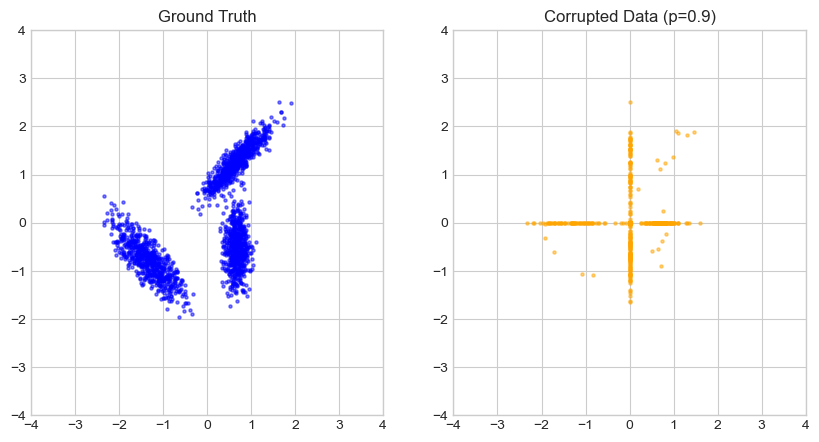

train_score_net: 100%|██████████| 20000/20000 [01:34<00:00, 210.55it/s]



--- Metrics for test0_gmm ---


,KDE_LogLikelihood,MMD,SWD
Standard,-1.407477,0.000244,0.001541
Naive (Collapsed),-2.449703,0.001555,0.009392
Ambient,-1.676647,0.002431,0.008754


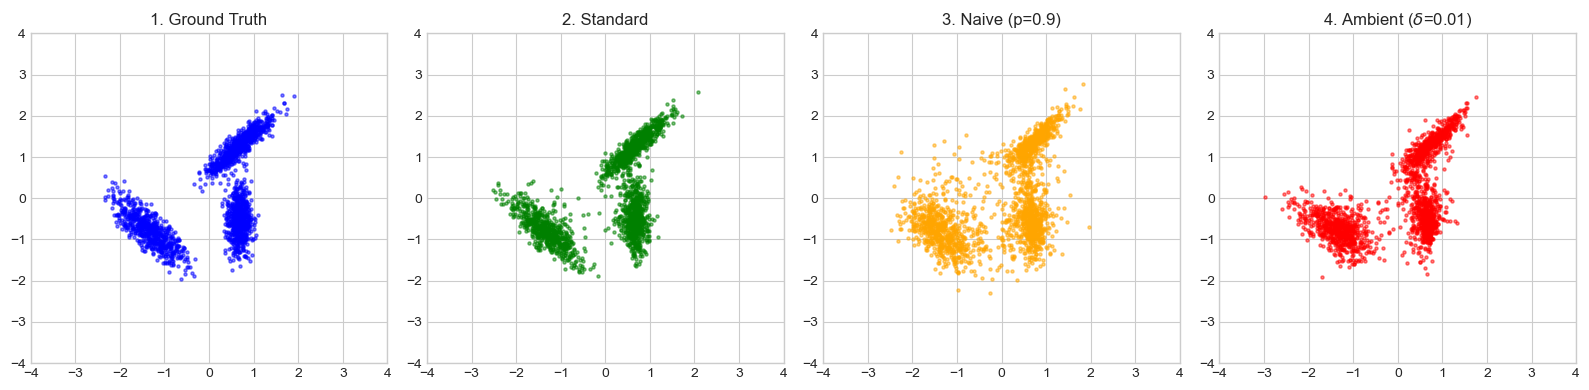

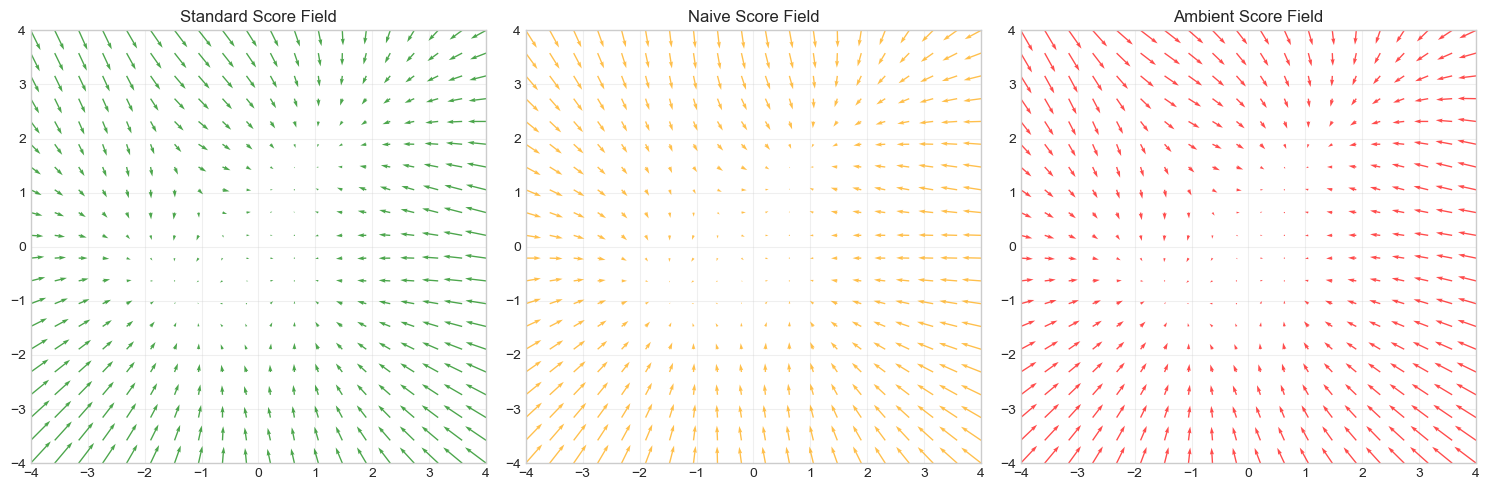

In [38]:
# GMM Distribution with 3 clusters
data_gmm_normal = generate_gmm(n_samples=10000)

mod_std_0, mod_nai_0, mod_amb_0, _ = run_standard_comparison(
    data=data_gmm_normal, 
    p_val=0.9, 
    delta_val=0.01, 
    epochs=20000, 
    hidden_dim=32, 
    bounds=(-4, 4), 
    exp_name="test0_gmm"
)

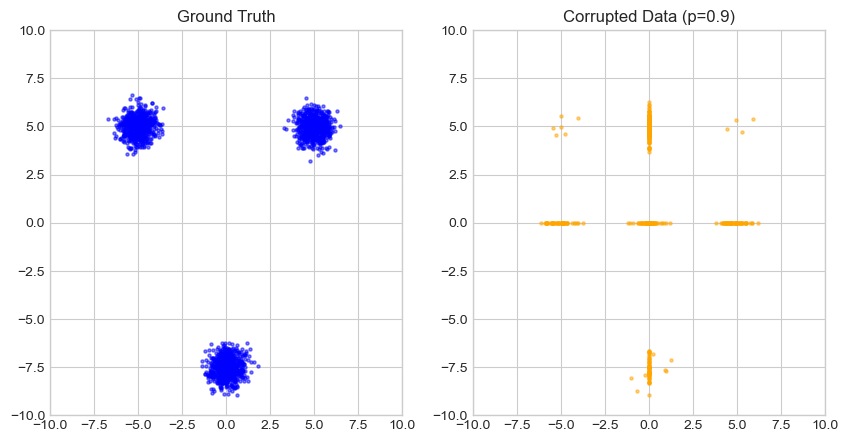

train_score_net: 100%|██████████| 20000/20000 [01:21<00:00, 245.43it/s]



--- Metrics for exp1_spread_gmm ---


,KDE_LogLikelihood,MMD,SWD
Standard,-2.767571,0.002442,0.479151
Naive (Collapsed),-53.799398,0.024187,1.856505
Ambient,-7.668344,0.036532,5.407260


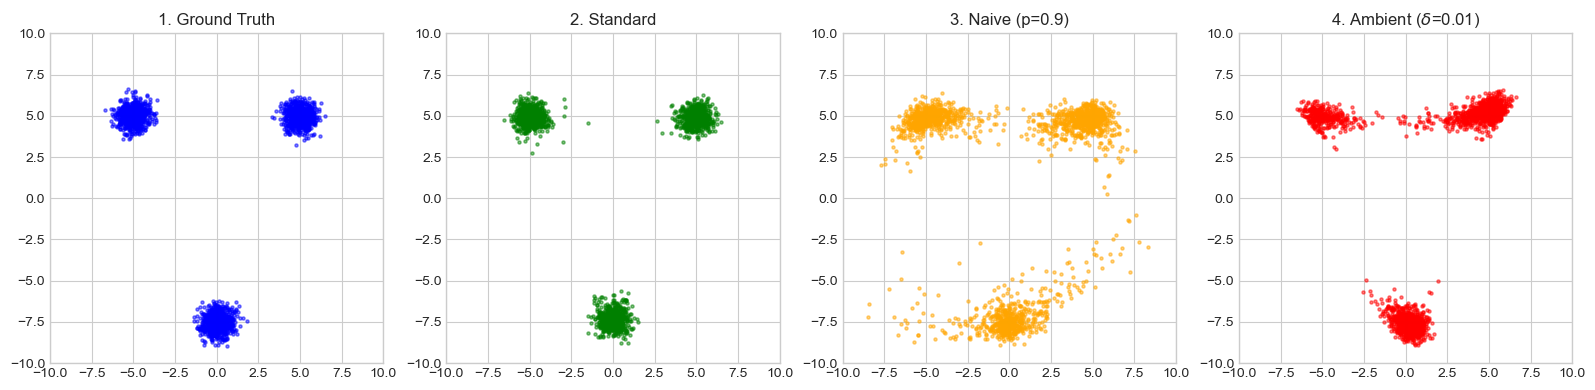

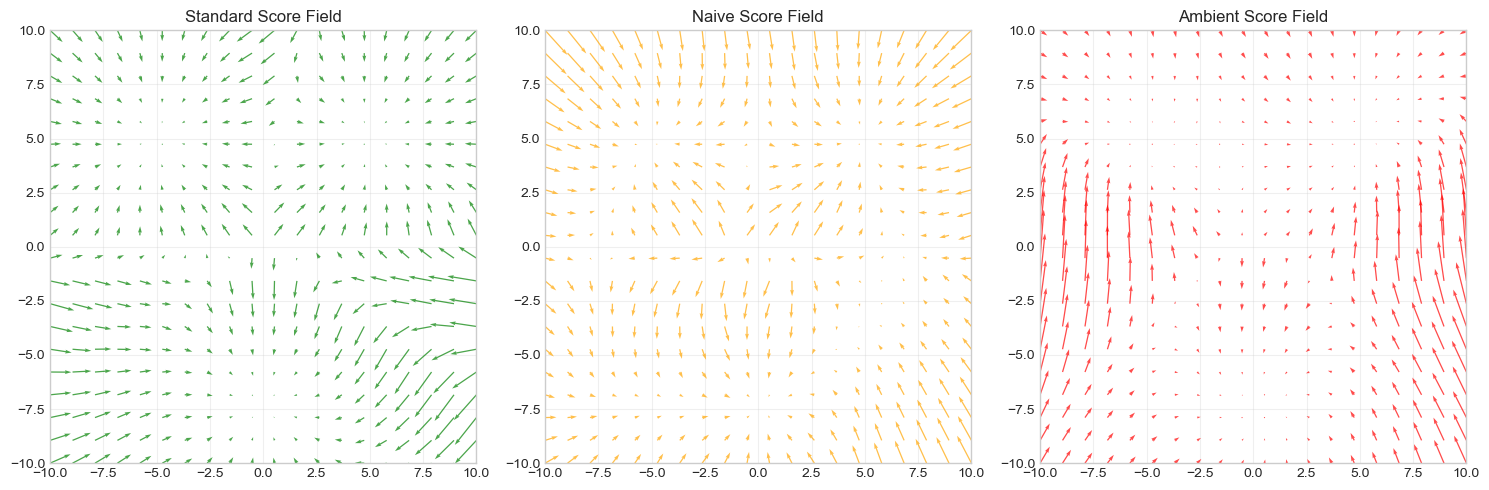

In [41]:
# GMM Distribution with 3 clusters far from the origin and axes (far from corrupted projections)
data_spread = generate_spread_gmm(n_samples=10000, distance=5.0)

mod_std_1, mod_nai_1, mod_amb_1, _ = run_standard_comparison(
    data=data_spread, 
    p_val=0.9, 
    delta_val=0.01, 
    epochs=20000, 
    hidden_dim=32, 
    bounds=(-10, 10), 
    exp_name="exp1_spread_gmm"
)

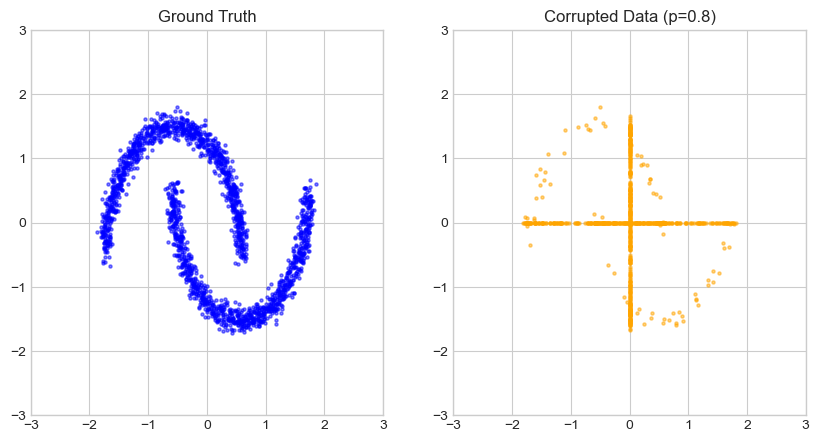

train_score_net: 100%|██████████| 50000/50000 [12:42<00:00, 65.62it/s] 



--- Metrics for exp2_two_moons ---


,KDE_LogLikelihood,MMD,SWD
Standard,-1.397641,0.002081,0.008851
Naive (Collapsed),-1.609368,0.000546,0.002509
Ambient,-1.692076,0.001291,0.004105


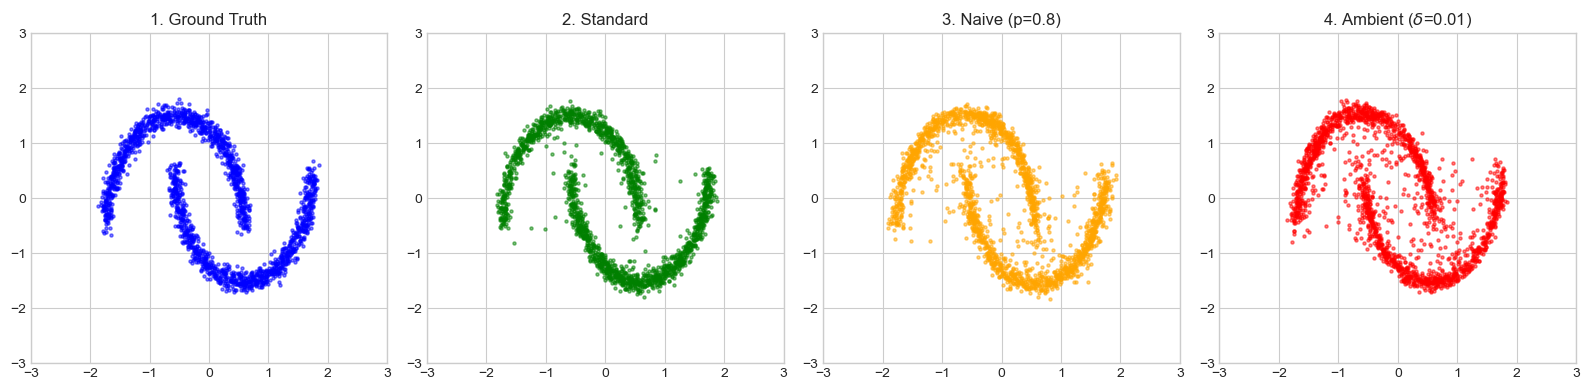

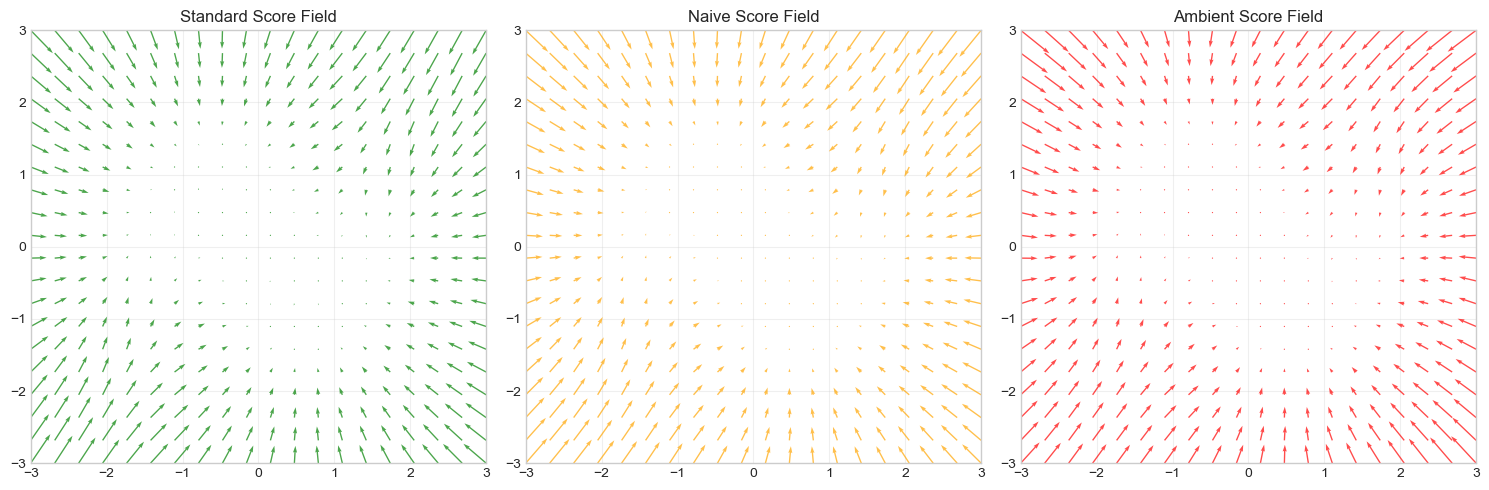

In [42]:
# Two Moons Distribution (more complex so higher hidden_dim and epochs and lower p)
data_moons = generate_two_moons(n_samples=10000, noise=0.05)

mod_std_2, mod_nai_2, mod_amb_2, _ = run_standard_comparison(
    data=data_moons, 
    p_val=0.8, 
    delta_val=0.01, 
    epochs=50000, 
    hidden_dim=256, 
    bounds=(-3, 3), 
    exp_name="exp2_two_moons"
)

train_score_net: 100%|██████████| 5000/5000 [00:20<00:00, 241.54it/s]



--- Metrics for p values ---


,KDE_LogLikelihood,MMD,SWD
p=0.3,-1.575082,0.001075,0.006563
p=0.5,-1.561238,0.001788,0.007012
p=0.7,-1.683560,0.004484,0.018008
p=0.9,-2.731618,0.005869,0.029775


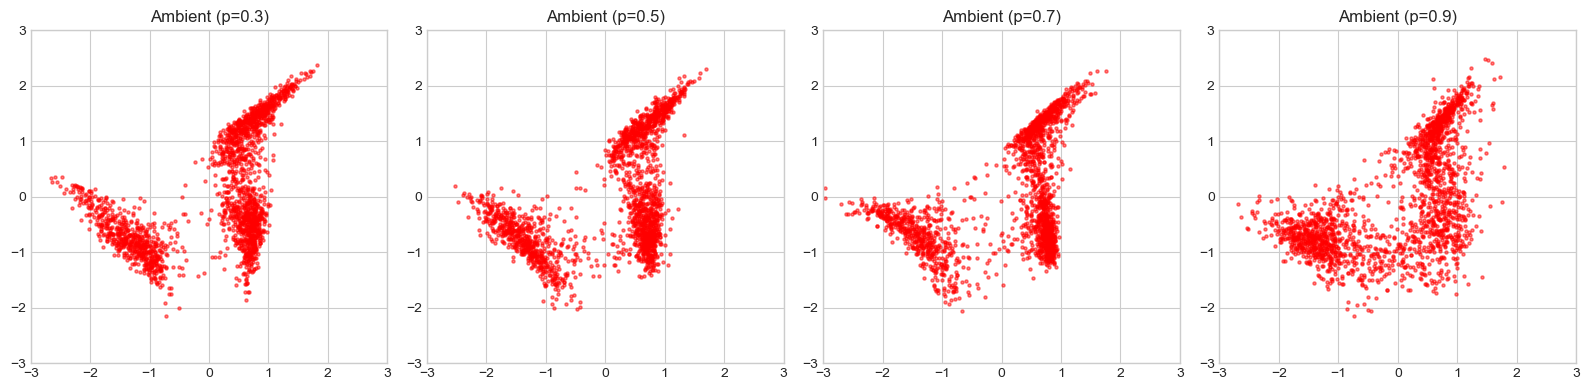

In [54]:
# Testing the effect of p on the spread GMM
sweep_p_values = [0.3, 0.5, 0.7, 0.9]
gens_p = []
metrics_p = {}
sigmas = get_scheduler(num_steps=100)

for p in sweep_p_values:
    op = ToyMaskingOperator(p=p, delta=0.02)
    mod, _ = train_score_net(PreconditionedScoreNet(hidden_dim=32), data_gmm_normal, op, epochs=5000)
    
    gen = sample_score_net(mod, 2000, sigmas)
    gens_p.append(gen)
    metrics_p[f"p={p}"] = compute_metrics(data_gmm_normal[:2000], torch.tensor(gen, dtype=torch.float32))

df_sweep_p = pd.DataFrame(metrics_p).T
print("\n--- Metrics for p values ---")
display(df_sweep_p)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i, p in enumerate(sweep_p_values):
    axs[i].scatter(gens_p[i][:, 0], gens_p[i][:, 1], s=5, alpha=0.5, c='red')
    axs[i].set_title(f"Ambient (p={p})")
    axs[i].set_xlim(-3, 3); axs[i].set_ylim(-3, 3)
plt.tight_layout()
plt.savefig("exp3_sweep_p.pdf")
plt.show()

train_score_net: 100%|██████████| 10000/10000 [00:37<00:00, 270.03it/s]



--- Metrics for delta values ---


,KDE_LogLikelihood,MMD,SWD
delta=0.001,-1.740650,0.000394,0.002728
delta=0.01,-1.620674,0.001848,0.016842
delta=0.1,-1.635603,0.000811,0.005435
delta=0.5,-3.163561,0.027640,0.052034


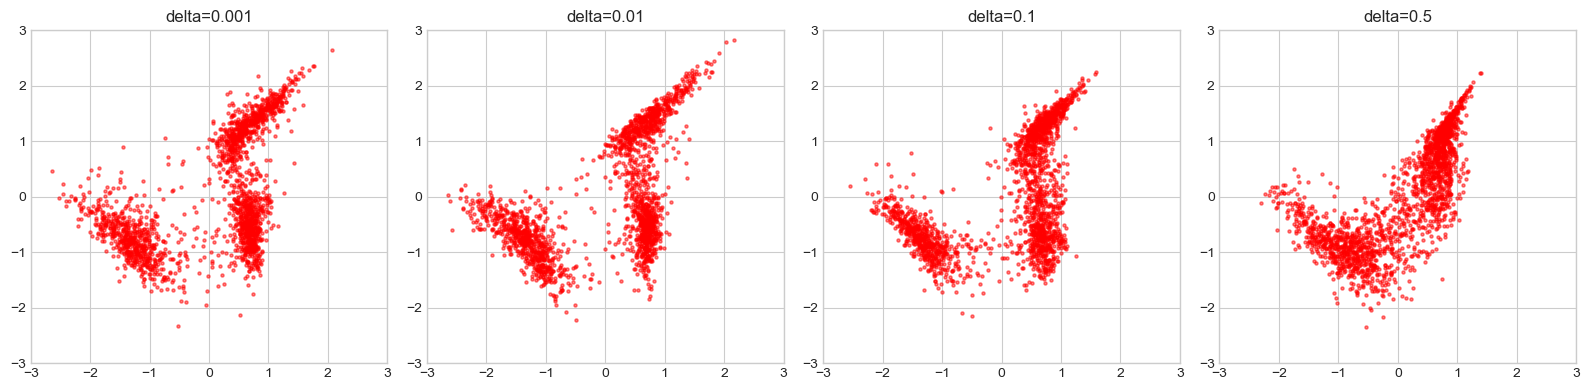

In [52]:
# Testing the effect of delta on the GMM normal
delta_values = [0.001, 0.01, 0.1, 0.5]
gens_delta = []
metrics_delta = {}

for d in delta_values:
    op = ToyMaskingOperator(p=0.7, delta=d)
    mod, _ = train_score_net(PreconditionedScoreNet(hidden_dim=32), data_gmm_normal, op, epochs=10000)
    
    gen = sample_score_net(mod, 2000, sigmas)
    gens_delta.append(gen)
    metrics_delta[f"delta={d}"] = compute_metrics(data_gmm_normal[:2000], torch.tensor(gen, dtype=torch.float32))

df_sweep_delta = pd.DataFrame(metrics_delta).T
print("\n--- Metrics for delta values ---")
display(df_sweep_delta)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
titles = [f"delta={d}" for d in delta_values]
for i, d in enumerate(delta_values):
    axs[i].scatter(gens_delta[i][:, 0], gens_delta[i][:, 1], s=5, alpha=0.5, c='red')
    axs[i].set_title(f"{titles[i]}")
    axs[i].set_xlim(-3, 3); axs[i].set_ylim(-3, 3)
plt.tight_layout()
plt.savefig("exp4_sweep_delta.pdf")
plt.show()